query shape: torch.Size([2, 10, 64])
context shape: torch.Size([2, 5, 64])
output shape: torch.Size([2, 10, 64])
attention head shape: torch.Size([2, 10, 5])


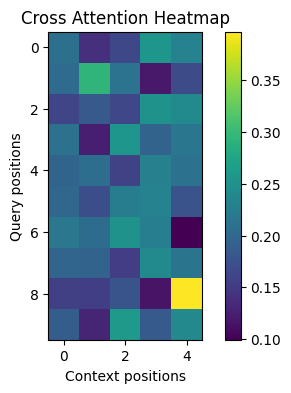

tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000])
Before attention: tensor([0.2222, 0.2202, 0.1827, 0.1795, 0.1954])
0 0.8748623728752136
100 1.8894092136179097e-05
200 3.422944705455677e-10
300 5.367468247641227e-08
400 3.385343437870003e-12
500 2.2152121914587042e-07
600 2.309714702483645e-12
700 1.3769652193636184e-14
800 4.840201484057616e-08
900 1.2251250361416943e-12


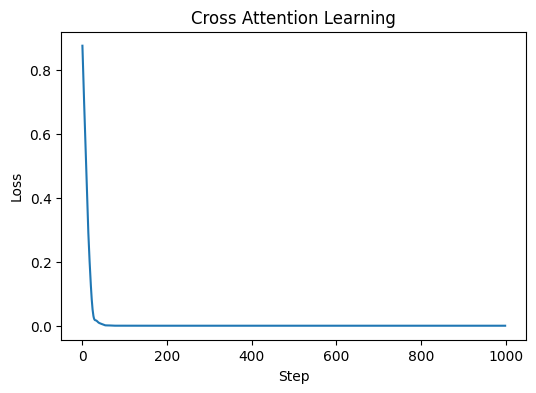

After training: tensor([0.0396, 0.0108, 0.9049, 0.0438, 0.0009])


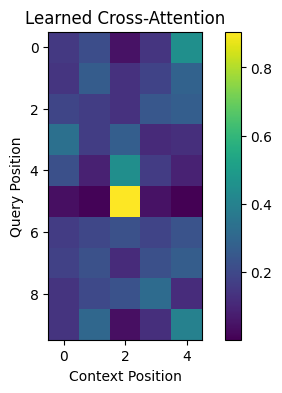

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
class CrossAttentionHead(nn.Module):

    def __init__(self, n_embd, head_size):
        super().__init__()

        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)

        self.last_attn = None

    def forward(self, x, context):

        # x: (B,Tq,C)
        # context: (B,Tc,C)

        q = self.query(x)
        k = self.key(context)
        v = self.value(context)

        wei = q @ k.transpose(-2, -1)

        wei = wei * (k.size(-1) ** -0.5)

        wei = F.softmax(wei, dim=-1)

        self.last_attn = wei.detach()

        out = wei @ v

        return out
class MultiHeadCrossAttention(nn.Module):

    def __init__(self, n_embd, n_head):

        super().__init__()

        head_size = n_embd // n_head

        self.heads = nn.ModuleList([
            CrossAttentionHead(n_embd, head_size)
            for _ in range(n_head)
        ])

        self.proj = nn.Linear(
            n_embd,
            n_embd
        )

    def forward(self, x, context):

        out = torch.cat(
            [h(x, context) for h in self.heads],
            dim=-1
        )

        return self.proj(out)

x = torch.randn(2, 10, 64).to(device)

context = torch.randn(2, 5, 64).to(device)

print("query shape:", x.shape)
print("context shape:",context.shape)

cross_attn = MultiHeadCrossAttention(
    n_embd=64,
    n_head=4
).to(device)

out = cross_attn(x, context)

print("output shape:", out.shape)

attn = cross_attn.heads[0].last_attn
print("attention head shape:", attn.shape)

attn_map = attn[0].cpu()
plt.figure(figsize=(6,4))

plt.imshow(attn_map)

plt.xlabel("Context positions")
plt.ylabel("Query positions")

plt.colorbar()

plt.title("Cross Attention Heatmap")

plt.show()
print(attn_map.sum(dim=-1))

#16
x = torch.randn(2,10,64).to(device)

context = torch.randn(2,5,64).to(device)

context[0,2] = x[0,5]

cross_attn = MultiHeadCrossAttention(
    n_embd=64,
    n_head=4
).to(device)

out = cross_attn(x, context)
attn = cross_attn.heads[0].last_attn[0]

print("Before attention:", attn[5])

target = context[0,2].detach()

optimizer = torch.optim.Adam(
    cross_attn.parameters(),
    lr=1e-3
)

losses = []

for step in range(1000):

    out = cross_attn(x, context)

    prediction = out[0,5]

    loss = F.mse_loss(
        prediction,
        target
    )

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    losses.append(loss.item())

    if step % 100 == 0:
        print(step, loss.item())

plt.figure(figsize=(6,4))

plt.plot(losses)

plt.xlabel("Step")
plt.ylabel("Loss")

plt.title("Cross Attention Learning")

plt.show()

out = cross_attn(x, context)

attn = cross_attn.heads[0].last_attn[0]

print("After training:", attn[5])

plt.figure(figsize=(6,4))

plt.imshow(attn.cpu())

plt.xlabel("Context Position")
plt.ylabel("Query Position")

plt.title("Learned Cross-Attention")

plt.colorbar()

plt.show()

